In [2]:
import torch
import snntorch as snn

print("Torch:", torch.__version__)
print("MPS:", torch.backends.mps.is_available())

Torch: 2.12.0
MPS: True


In [7]:
import torch
import snntorch as snn

# Leak parameter
beta = 0.9

# Create a Leaky Integrate-and-Fire neuron
lif = snn.Leaky(beta=beta)

# Initial membrane potential
mem = torch.zeros(1)

for t in range(20):

    # Constant input current
    current = torch.tensor([0.25])

    # Update neuron
    spk, mem = lif(current, mem)

    print(
        f"t={t:02d}",
        f"spike={spk.item():.0f}",
        f"mem={mem.item():.3f}"
    )

t=00 spike=0 mem=0.250
t=01 spike=0 mem=0.475
t=02 spike=0 mem=0.678
t=03 spike=0 mem=0.860
t=04 spike=1 mem=1.024
t=05 spike=0 mem=0.171
t=06 spike=0 mem=0.404
t=07 spike=0 mem=0.614
t=08 spike=0 mem=0.802
t=09 spike=0 mem=0.972
t=10 spike=1 mem=1.125
t=11 spike=0 mem=0.262
t=12 spike=0 mem=0.486
t=13 spike=0 mem=0.688
t=14 spike=0 mem=0.869
t=15 spike=1 mem=1.032
t=16 spike=0 mem=0.179
t=17 spike=0 mem=0.411
t=18 spike=0 mem=0.620
t=19 spike=0 mem=0.808


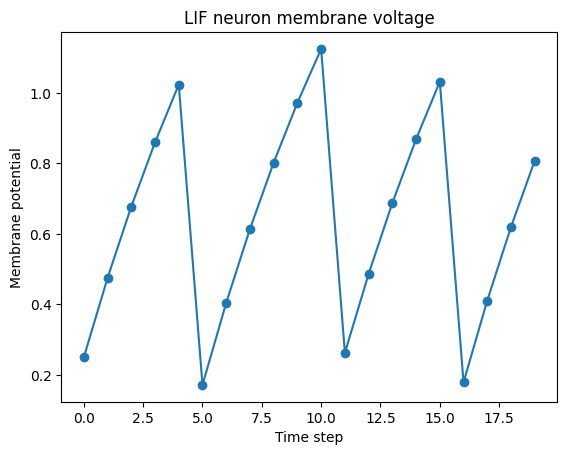

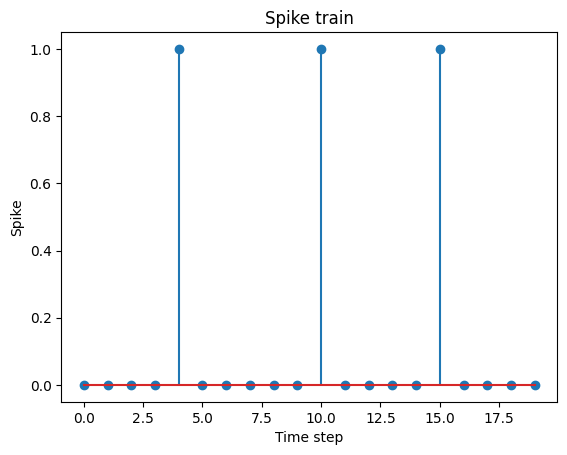

In [8]:
import matplotlib.pyplot as plt

lif = snn.Leaky(beta=0.9)
mem = torch.zeros(1)

mem_rec = []
spk_rec = []

for t in range(20):
    current = torch.tensor([0.25])
    spk, mem = lif(current, mem)

    mem_rec.append(mem.item())
    spk_rec.append(spk.item())

plt.figure()
plt.plot(mem_rec, marker="o")
plt.xlabel("Time step")
plt.ylabel("Membrane potential")
plt.title("LIF neuron membrane voltage")
plt.show()

plt.figure()
plt.stem(spk_rec)
plt.xlabel("Time step")
plt.ylabel("Spike")
plt.title("Spike train")
plt.show()

In [9]:
lif = snn.Leaky(beta=0.9)
mem = torch.zeros(1)

for t in range(20):
    current = torch.tensor([0.05])
    spk, mem = lif(current, mem)
    print(f"t={t:02d} spike={spk.item():.0f} mem={mem.item():.3f}")

t=00 spike=0 mem=0.050
t=01 spike=0 mem=0.095
t=02 spike=0 mem=0.135
t=03 spike=0 mem=0.172
t=04 spike=0 mem=0.205
t=05 spike=0 mem=0.234
t=06 spike=0 mem=0.261
t=07 spike=0 mem=0.285
t=08 spike=0 mem=0.306
t=09 spike=0 mem=0.326
t=10 spike=0 mem=0.343
t=11 spike=0 mem=0.359
t=12 spike=0 mem=0.373
t=13 spike=0 mem=0.386
t=14 spike=0 mem=0.397
t=15 spike=0 mem=0.407
t=16 spike=0 mem=0.417
t=17 spike=0 mem=0.425
t=18 spike=0 mem=0.432
t=19 spike=0 mem=0.439


In [10]:
lif = snn.Leaky(beta=0.9)
mem = torch.zeros(1)

for t in range(20):
    current = torch.tensor([0.6])
    spk, mem = lif(current, mem)
    print(f"t={t:02d} spike={spk.item():.0f} mem={mem.item():.3f}")

t=00 spike=0 mem=0.600
t=01 spike=1 mem=1.140
t=02 spike=0 mem=0.626
t=03 spike=1 mem=1.163
t=04 spike=0 mem=0.647
t=05 spike=1 mem=1.182
t=06 spike=0 mem=0.664
t=07 spike=1 mem=1.198
t=08 spike=0 mem=0.678
t=09 spike=1 mem=1.210
t=10 spike=0 mem=0.689
t=11 spike=1 mem=1.220
t=12 spike=0 mem=0.698
t=13 spike=1 mem=1.228
t=14 spike=0 mem=0.706
t=15 spike=1 mem=1.235
t=16 spike=0 mem=0.711
t=17 spike=1 mem=1.240
t=18 spike=0 mem=0.716
t=19 spike=1 mem=1.245


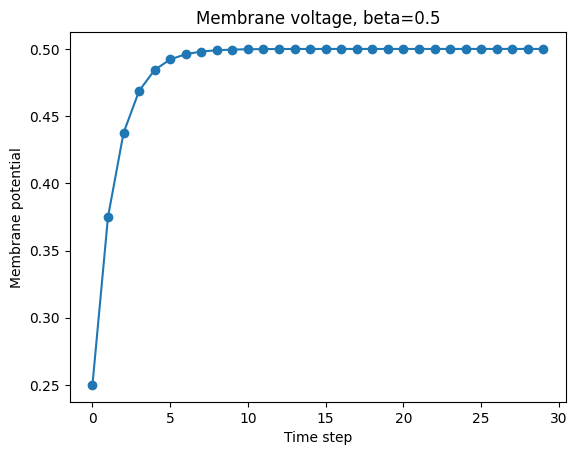

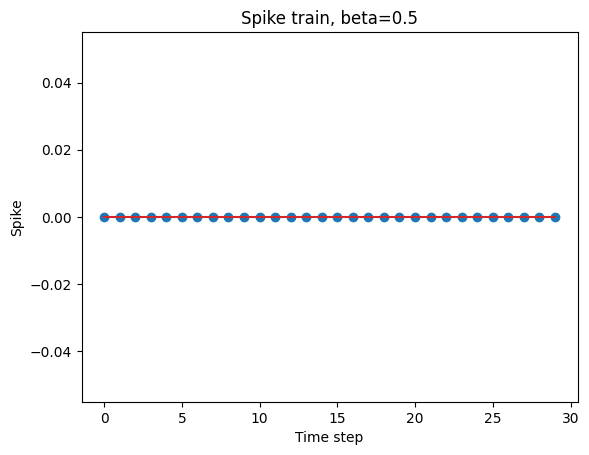

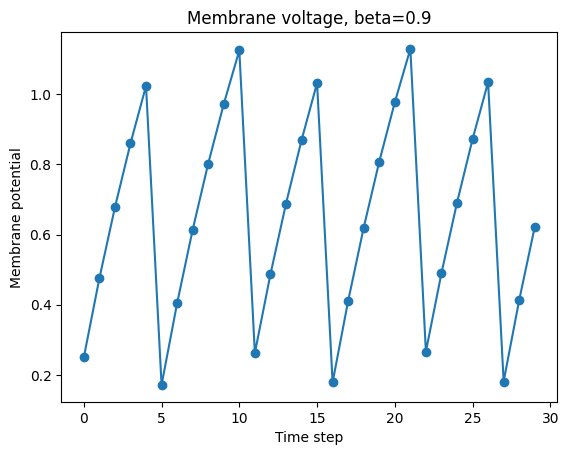

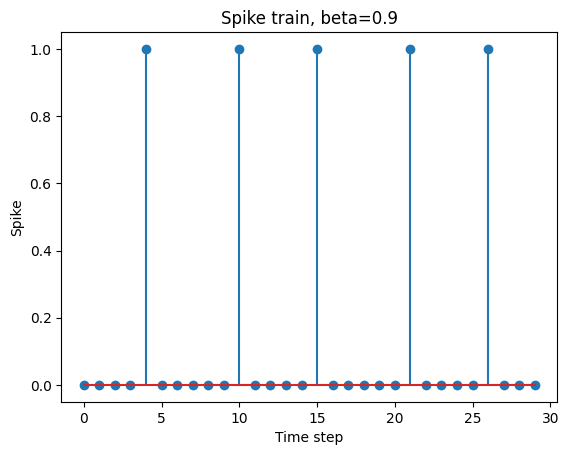

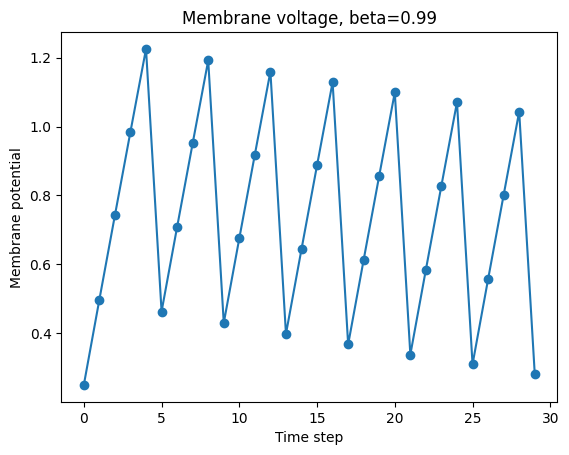

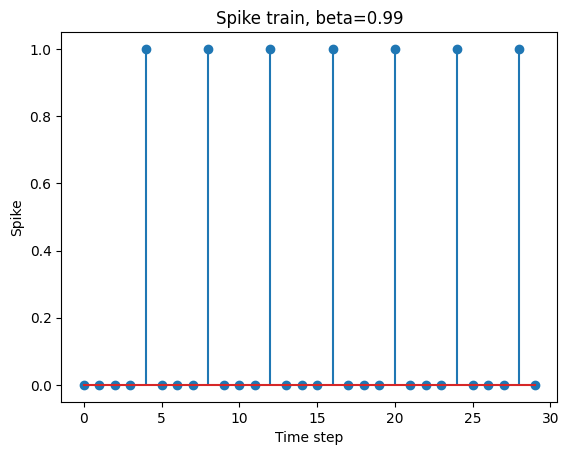

In [11]:
import torch
import snntorch as snn
import matplotlib.pyplot as plt

def run_lif(beta, current_value, steps=30):
    lif = snn.Leaky(beta=beta)
    mem = torch.zeros(1)

    mem_rec = []
    spk_rec = []

    for t in range(steps):
        current = torch.tensor([current_value])
        spk, mem = lif(current, mem)

        mem_rec.append(mem.item())
        spk_rec.append(spk.item())

    return mem_rec, spk_rec


for beta in [0.5, 0.9, 0.99]:
    mem_rec, spk_rec = run_lif(beta=beta, current_value=0.25)

    plt.figure()
    plt.plot(mem_rec, marker="o")
    plt.title(f"Membrane voltage, beta={beta}")
    plt.xlabel("Time step")
    plt.ylabel("Membrane potential")
    plt.show()

    plt.figure()
    plt.stem(spk_rec)
    plt.title(f"Spike train, beta={beta}")
    plt.xlabel("Time step")
    plt.ylabel("Spike")
    plt.show()

Trying a time-varying input

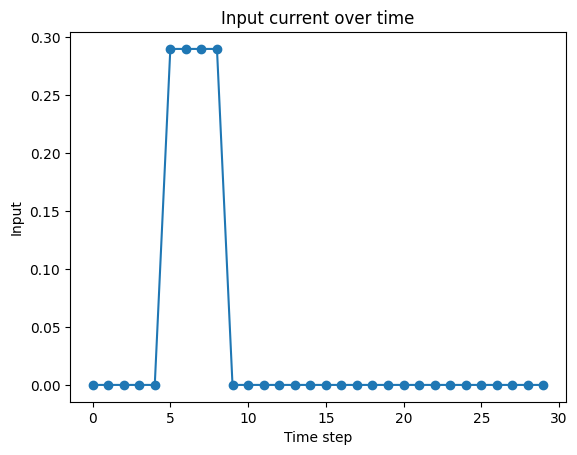

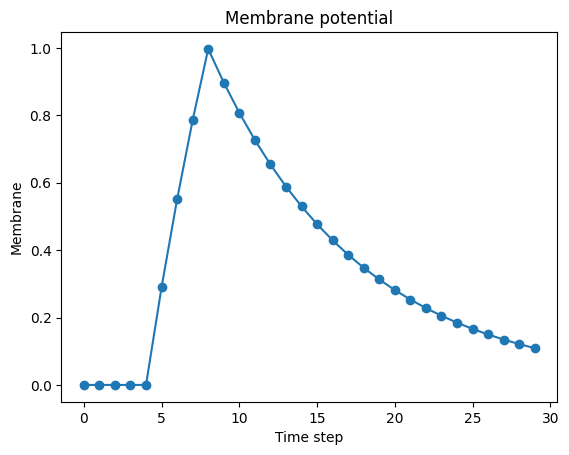

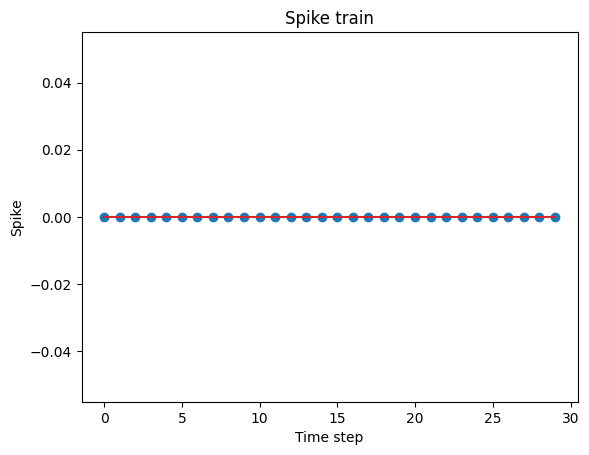

In [18]:
import torch
import snntorch as snn
import matplotlib.pyplot as plt

lif = snn.Leaky(beta=0.9)
mem = torch.zeros(1)

# Object appears briefly at t=5,6,7,8
inputs = torch.zeros(30)
inputs[5:9] = 0.29

mem_rec = []
spk_rec = []

for t in range(len(inputs)):
    current = inputs[t].reshape(1)
    spk, mem = lif(current, mem)

    mem_rec.append(mem.item())
    spk_rec.append(spk.item())

plt.figure()
plt.plot(inputs, marker="o")
plt.title("Input current over time")
plt.xlabel("Time step")
plt.ylabel("Input")
plt.show()

plt.figure()
plt.plot(mem_rec, marker="o")
plt.title("Membrane potential")
plt.xlabel("Time step")
plt.ylabel("Membrane")
plt.show()

plt.figure()
plt.stem(spk_rec)
plt.title("Spike train")
plt.xlabel("Time step")
plt.ylabel("Spike")
plt.show()

Trying a buffer of size 4

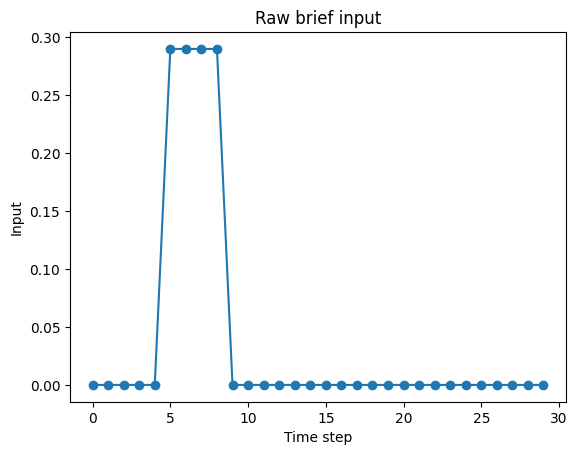

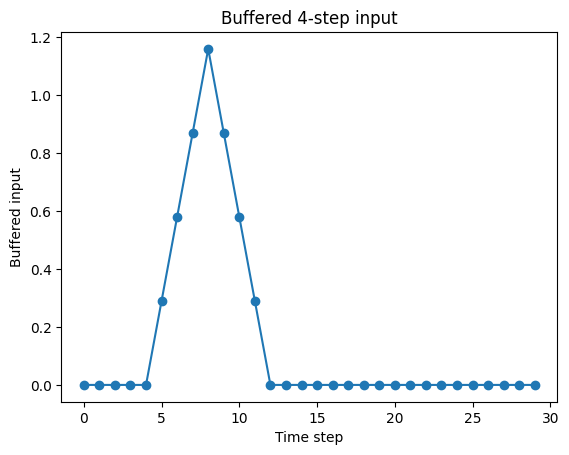

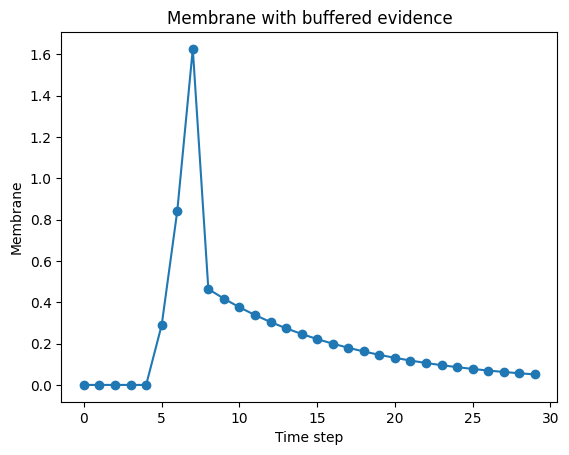

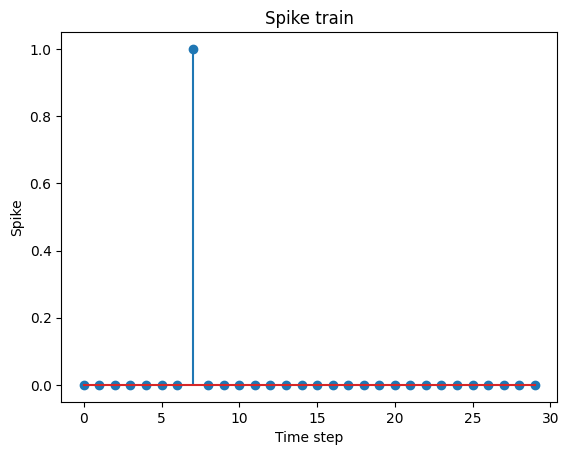

In [24]:
import torch
import snntorch as snn
import matplotlib.pyplot as plt

lif = snn.Leaky(beta=0.9)
mem = torch.zeros(1)

# Weak object evidence: individually too weak
raw_inputs = torch.zeros(30)
raw_inputs[5:9] = 0.29

# 4-step memory buffer: accumulate recent evidence
buffer_size = 4
buffered_inputs = torch.zeros_like(raw_inputs)

for t in range(len(raw_inputs)):
    start = max(0, t - buffer_size + 1)
    buffered_inputs[t] = raw_inputs[start:t+1].sum()

mem_rec = []
spk_rec = []

decision_made = False

for t in range(len(buffered_inputs)):
    current = buffered_inputs[t].reshape(1)

    if decision_made:
        current = torch.zeros(1)

    spk, mem = lif(current, mem)

    if spk.item() == 1:
        decision_made = True

    mem_rec.append(mem.item())
    spk_rec.append(spk.item())

plt.figure()
plt.plot(raw_inputs, marker="o")
plt.title("Raw brief input")
plt.xlabel("Time step")
plt.ylabel("Input")
plt.show()

plt.figure()
plt.plot(buffered_inputs, marker="o")
plt.title("Buffered 4-step input")
plt.xlabel("Time step")
plt.ylabel("Buffered input")
plt.show()

plt.figure()
plt.plot(mem_rec, marker="o")
plt.title("Membrane with buffered evidence")
plt.xlabel("Time step")
plt.ylabel("Membrane")
plt.show()

plt.figure()
plt.stem(spk_rec)
plt.title("Spike train")
plt.xlabel("Time step")
plt.ylabel("Spike")
plt.show()

Trying a buffer of size 2

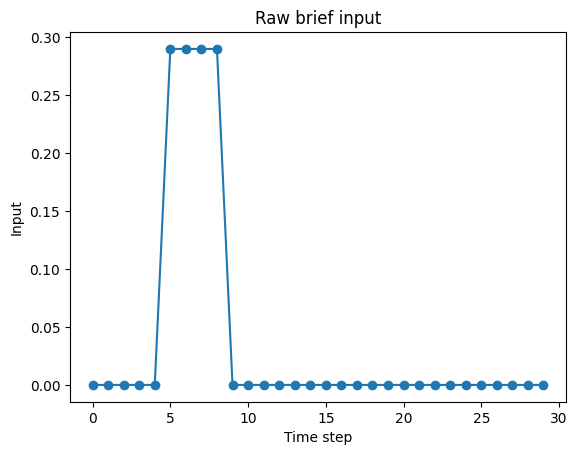

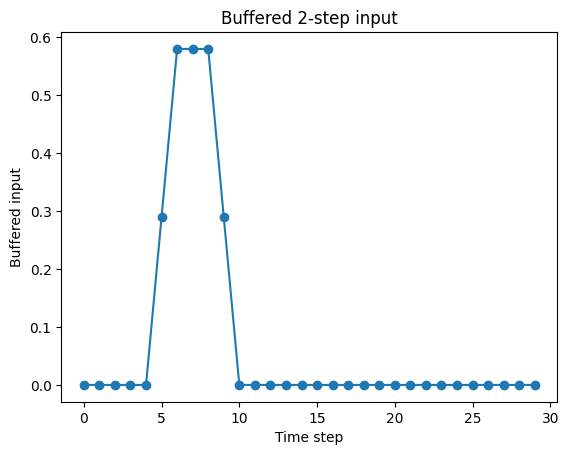

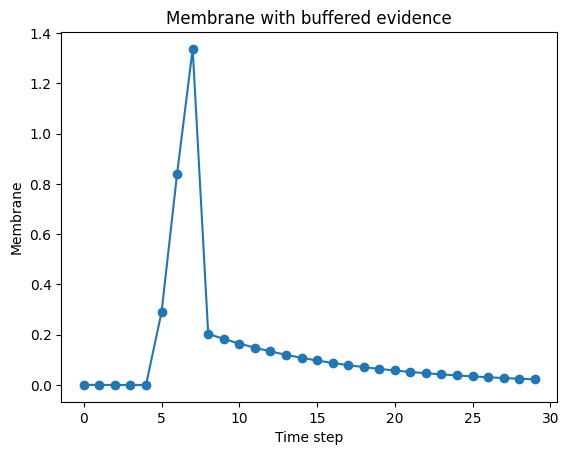

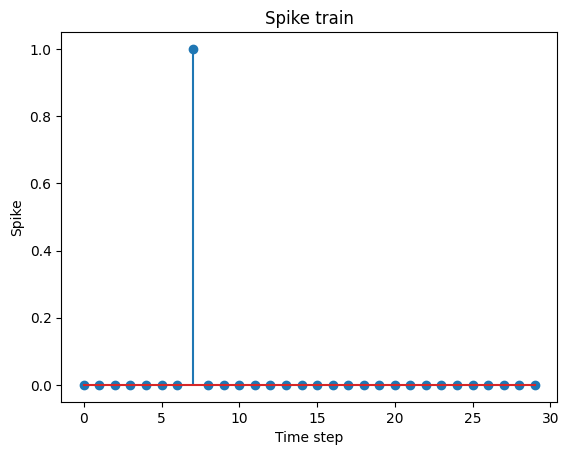

In [25]:
import torch
import snntorch as snn
import matplotlib.pyplot as plt

lif = snn.Leaky(beta=0.9)
mem = torch.zeros(1)

# Weak object evidence: individually too weak
raw_inputs = torch.zeros(30)
raw_inputs[5:9] = 0.29

# 4-step memory buffer: accumulate recent evidence
buffer_size = 2
buffered_inputs = torch.zeros_like(raw_inputs)

for t in range(len(raw_inputs)):
    start = max(0, t - buffer_size + 1)
    buffered_inputs[t] = raw_inputs[start:t+1].sum()

mem_rec = []
spk_rec = []

decision_made = False

for t in range(len(buffered_inputs)):
    current = buffered_inputs[t].reshape(1)

    if decision_made:
        current = torch.zeros(1)

    spk, mem = lif(current, mem)

    if spk.item() == 1:
        decision_made = True

    mem_rec.append(mem.item())
    spk_rec.append(spk.item())

plt.figure()
plt.plot(raw_inputs, marker="o")
plt.title("Raw brief input")
plt.xlabel("Time step")
plt.ylabel("Input")
plt.show()

plt.figure()
plt.plot(buffered_inputs, marker="o")
plt.title("Buffered 2-step input")
plt.xlabel("Time step")
plt.ylabel("Buffered input")
plt.show()

plt.figure()
plt.plot(mem_rec, marker="o")
plt.title("Membrane with buffered evidence")
plt.xlabel("Time step")
plt.ylabel("Membrane")
plt.show()

plt.figure()
plt.stem(spk_rec)
plt.title("Spike train")
plt.xlabel("Time step")
plt.ylabel("Spike")
plt.show()

Binary spike response sweep


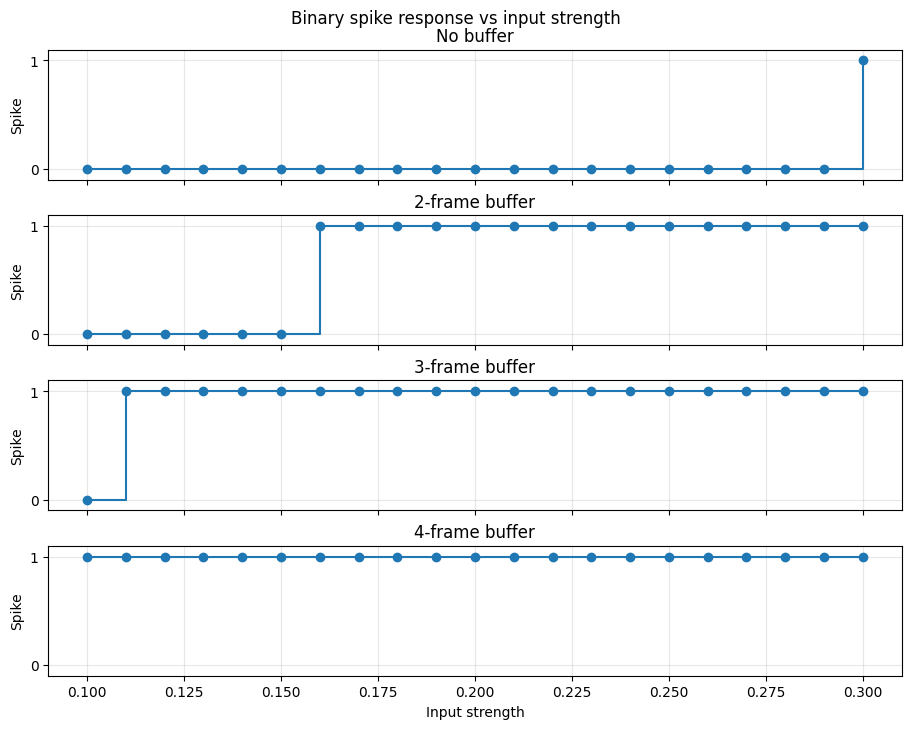

In [4]:
import torch
import snntorch as snn
import matplotlib.pyplot as plt

beta = 0.9
steps = 30
input_start = 5
input_duration = 4
input_strengths = torch.linspace(0.10, 0.30, steps=21)  # 0.01 intervals
buffer_configs = [
    ("No buffer", None),
    ("2-frame buffer", 2),
    ("3-frame buffer", 3),
    ("4-frame buffer", 4),
]


def make_raw_inputs(input_strength):
    raw_inputs = torch.zeros(steps)
    raw_inputs[input_start:input_start + input_duration] = input_strength
    return raw_inputs


def apply_buffer(raw_inputs, buffer_size):
    if buffer_size is None:
        return raw_inputs.clone()

    buffered_inputs = torch.zeros_like(raw_inputs)
    for t in range(len(raw_inputs)):
        start = max(0, t - buffer_size + 1)
        buffered_inputs[t] = raw_inputs[start:t + 1].sum()
    return buffered_inputs


def did_spike(input_strength, buffer_size):
    lif = snn.Leaky(beta=beta)
    mem = torch.zeros(1)
    raw_inputs = make_raw_inputs(input_strength)
    lif_inputs = apply_buffer(raw_inputs, buffer_size)

    for t in range(len(lif_inputs)):
        current = lif_inputs[t].reshape(1)
        spk, mem = lif(current, mem)
        if spk.item() == 1:
            return 1

    return 0


fig, axes = plt.subplots(
    len(buffer_configs),
    1,
    figsize=(9, 7),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

for ax, (label, buffer_size) in zip(axes, buffer_configs):
    spikes = [did_spike(float(input_strength), buffer_size) for input_strength in input_strengths]
    ax.plot(input_strengths.numpy(), spikes, marker="o", drawstyle="steps-post")
    ax.set_title(label)
    ax.set_ylabel("Spike")
    ax.set_yticks([0, 1])
    ax.set_ylim(-0.1, 1.1)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Input strength")
fig.suptitle("Binary spike response vs input strength", y=1.02)
plt.show()

